In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx
from tensorflow_probability.substrates.jax import distributions
from tqdm import tqdm
from confrdm_jax.flows import evaluate_pdf_sf
from confrdm_jax.flows import load_conditioner
from confrdm_jax.flows import make_mlp_conditioner
from confrdm_jax.flows import save_conditioner
from confrdm_jax.flows import spline_flow
from confrdm_jax.flows import train_step
from confrdm_jax.simulators import create_wald_prior_informed
from confrdm_jax.simulators import sample_conditional_wald

In [3]:
prior = create_wald_prior_informed()

samples = prior.sample(seed=1234, sample_shape=(10, 3))

In [4]:
key = jax.random.key(seed=1234)

data, context = sample_conditional_wald(key, (10, 5), prior)

In [5]:
data.shape, context.shape

((10, 5, 1), (10, 1, 3))

In [6]:
rngs = nnx.Rngs(0)

conditioner = make_mlp_conditioner(num_in=3, num_bins=8, rngs=rngs)
x = conditioner(context)
x.shape

(10, 1, 25)

In [7]:
log_probs, _ = spline_flow(data.squeeze(), context, conditioner)
jnp.where(jnp.isnan(log_probs))

(Array([], shape=(0,), dtype=int32), Array([], shape=(0,), dtype=int32))

In [8]:
def ref_log_pdf_sf(data, v, s, b):
    # mu_winner = b/drift_winner
    mu = b / v
    # lam_winner = (b/s_winner)**2
    lam = (b / s)**2

    dist = distributions.InverseGaussian(mu, lam)

    return dist.log_prob(data), dist.log_survival_function(data)

In [9]:
train_steps = 50_000

eval_every = int(train_steps // 10)

batch_shape = (64, 200)

metrics_history = {
  "train_loss": [],
}

master_key = jax.random.key(2027)
train_key, test_key = jax.random.split(master_key)
conditioner_key, sampling_key = jax.random.split(train_key, 2)

rngs = nnx.Rngs(default=conditioner_key, sampling=sampling_key)

conditioner = make_mlp_conditioner(num_in=3, num_bins=4, rngs=rngs)

learning_rate = 0.005 # optax.schedules.cosine_decay_schedule(0.005, train_steps, 1e-6)

optimizer = nnx.Optimizer(
  conditioner, optax.adamw(learning_rate), wrt=nnx.Param,
)
metrics = nnx.MultiMetric(
  loss=nnx.metrics.Average("loss"),
)

for step in tqdm(range(train_steps)):
  data, context = sample_conditional_wald(rngs.sampling(), batch_shape, prior)

  conditioner.train()

  train_step(conditioner, optimizer, metrics, data, context)

  if step > 0 and (step % eval_every == 0 or step == train_steps - 1):  # One training epoch has passed.
    for metric, value in metrics.compute().items():  # Compute the metrics.
      metrics_history[f"train_{metric}"].append(value)  # Record the metrics.

    metrics.reset()  # Reset the metrics for the test set.

    print(value)

save_conditioner(conditioner, Path("conditioner").absolute())

 10%|█         | 5053/50000 [00:15<02:05, 356.94it/s]

-0.38494226


 20%|██        | 10059/50000 [00:29<01:47, 371.13it/s]

-0.42330718


 30%|███       | 15066/50000 [00:42<01:33, 374.38it/s]

...

-0.4307554


 90%|█████████ | 45035/50000 [02:43<00:22, 219.01it/s]

-0.43025234


100%|██████████| 50000/50000 [03:04<00:00, 270.75it/s]


-0.43438312


In [59]:
test_data, test_context = sample_conditional_wald(test_key, (500,), prior)
# test_data = test_data.squeeze()
# test_context = test_context.squeeze()

In [60]:
test_data.shape, test_context.shape

((500, 1), (1, 3))

In [61]:
test_pdf, test_sf = evaluate_pdf_sf(conditioner, test_data, test_context)
test_pdf.shape, test_sf.shape

((500, 1), (500, 1))

In [62]:
ref_pdf, ref_sf = ref_log_pdf_sf(test_data, test_context[..., 0], test_context[..., 1], test_context[..., 2])
ref_pdf.shape, ref_sf.shape

((500, 1), (500, 1))

In [63]:
jax.scipy.special.kl_div(jnp.exp(ref_pdf), jnp.exp(test_pdf)).mean()
# jax.scipy.special.kl_div(jnp.exp(ref_sf), jnp.exp(test_sf)).mean()

Array(0.00054584, dtype=float32)

Text(0.5, 0, 'RT (in s)')

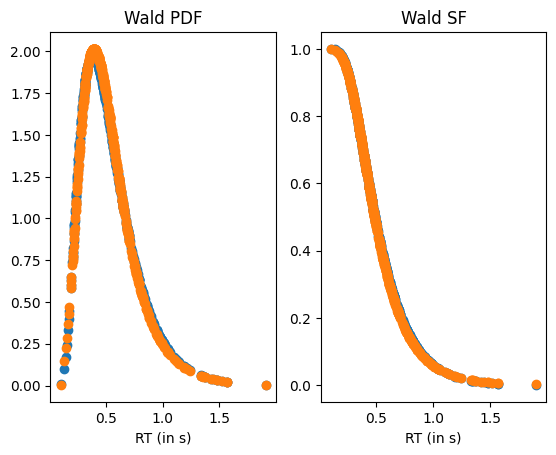

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(test_data, jnp.exp(ref_pdf), "o", label="Reference")
ax1.plot(test_data, jnp.exp(test_pdf), "o", label="Approx")

ax1.set_xlabel("RT (in s)")
ax1.set_title("Wald PDF")

ax2.plot(test_data, jnp.exp(ref_sf), "o", label="Reference")
ax2.plot(test_data, jnp.exp(test_sf), "o", label="Approx")

ax2.set_title("Wald SF")
ax2.set_xlabel("RT (in s)")

In [66]:
@jax.jit
def inv_gauss_log_pdf_sf(rt, v, b, s, t0):
    rt = rt - t0
    rt = jnp.maximum(0.0, rt)

    return evaluate_pdf_sf(conditioner, rt, jnp.array([v, s, b]))

def create_rdm_two_accumulators_likelihood(data):
    rt = data[:, 0]
    choice = data[:, 1]

    @jax.jit
    def likelihood_fun(x, min_ll=1e-12):
        x = jnp.exp(x)

        v_true = x[0] + x[1]
        v_false = x[0]
        s_true = x[2]
        s_false = 1.0
        b = x[3]
        t0 = x[4]

        log_pdf_true, log_sf_true = inv_gauss_log_pdf_sf(rt, v_true, b, s_true, t0)
        log_pdf_false, log_sf_false = inv_gauss_log_pdf_sf(rt, v_false, b, s_false, t0)

        dens_true = log_pdf_true.squeeze() + log_sf_false.squeeze()
        dens_false = log_pdf_false.squeeze() + log_sf_true.squeeze()

        ll = jnp.where(choice == 1, dens_true, dens_false)

        return jnp.where(jnp.isfinite(ll), ll, jnp.log(min_ll))

    return likelihood_fun

import numpy as np
from confrdm.simulators.rdm import simulate_rdm_two_accumulators

test_params = dict(
    v_intercept=1.0,
    v_slope=3.0,
    s_true=1.2,
    b=1.2,
    t0=0.3,
)

test_data = simulate_rdm_two_accumulators(
    **test_params,
    num_obs=500,
    rng=np.random.default_rng(2027),
)["x"]

rdm_likelihood = create_rdm_two_accumulators_likelihood(test_data)

In [67]:
from jax.scipy import stats


@jax.jit
def rdm_prior(x):
    def scale_logtruncnorm(x, loc, scale, a):
        return stats.truncnorm.logpdf(x, loc=loc, scale=scale, a=(a - loc) / scale, b=jnp.inf)

    x = jnp.exp(x)
    v_intercept = scale_logtruncnorm(x[0], 1.0, 0.5, 0.0)
    v_slope = scale_logtruncnorm(x[1], 4.0, 0.5, 0.0)
    s_true = scale_logtruncnorm(x[2], 1.0, 0.25, 0.0)
    b = stats.gamma.logpdf(x[3], a=12.0, scale=0.15)
    t0 = scale_logtruncnorm(x[4], 0.3, 0.2, 0.0)

    return v_intercept + v_slope + s_true + b + t0

In [68]:
import blackjax


def inference_loop_multiple_chains(
    rng_key, kernel, initial_state, num_samples, num_chains,
):
    @jax.jit
    def one_step(states, rng_key):
        keys = jax.random.split(rng_key, num_chains)
        states, _ = jax.vmap(kernel)(keys, states)
        return states, states

    keys = jax.random.split(rng_key, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)

    return states


def warmup(sampler_fun, logdensity_fun, init_position, num_steps, rng_key, **kwargs):
    adapt = blackjax.window_adaptation(sampler_fun, logdensity_fun, **kwargs)
    (last_state, parameters), _ = adapt.run(rng_key, init_position, num_steps=num_steps)
    kernel = sampler_fun(logdensity_fun, **parameters).step
    return kernel, last_state, parameters

In [69]:
@jax.jit
def logdensity_fun(x):
    return rdm_prior(x) + jnp.sum(rdm_likelihood(x))

In [70]:
init_position = jnp.array([1.0, 4.0, 1.0, 0.8, 0.2])
logdensity_fun(jnp.log(init_position))

Array(-955.00226, dtype=float32)

In [71]:
rng_key = jax.random.key(2025)

rng_key, warmup_key = jax.random.split(rng_key)

kernel, last_state, warmup_parameters = warmup(
    blackjax.nuts,
    logdensity_fun,
    jnp.log(init_position),
    2000,
    warmup_key,
    progress_bar=True,
)

Running window adaptation


In [72]:
jnp.exp(last_state.position)

Array([1.609402  , 3.5132754 , 1.3717577 , 1.3017421 , 0.31684858],      dtype=float32)

In [73]:
num_chains = 4

last_states = jax.vmap(lambda x: last_state)(np.arange(num_chains))

trace = inference_loop_multiple_chains(
    rng_key, kernel, last_states, 2000, num_chains,
)

samples = np.moveaxis(np.asarray(jnp.exp(trace.position)), (0, 1, 2), (2, 1, 0))

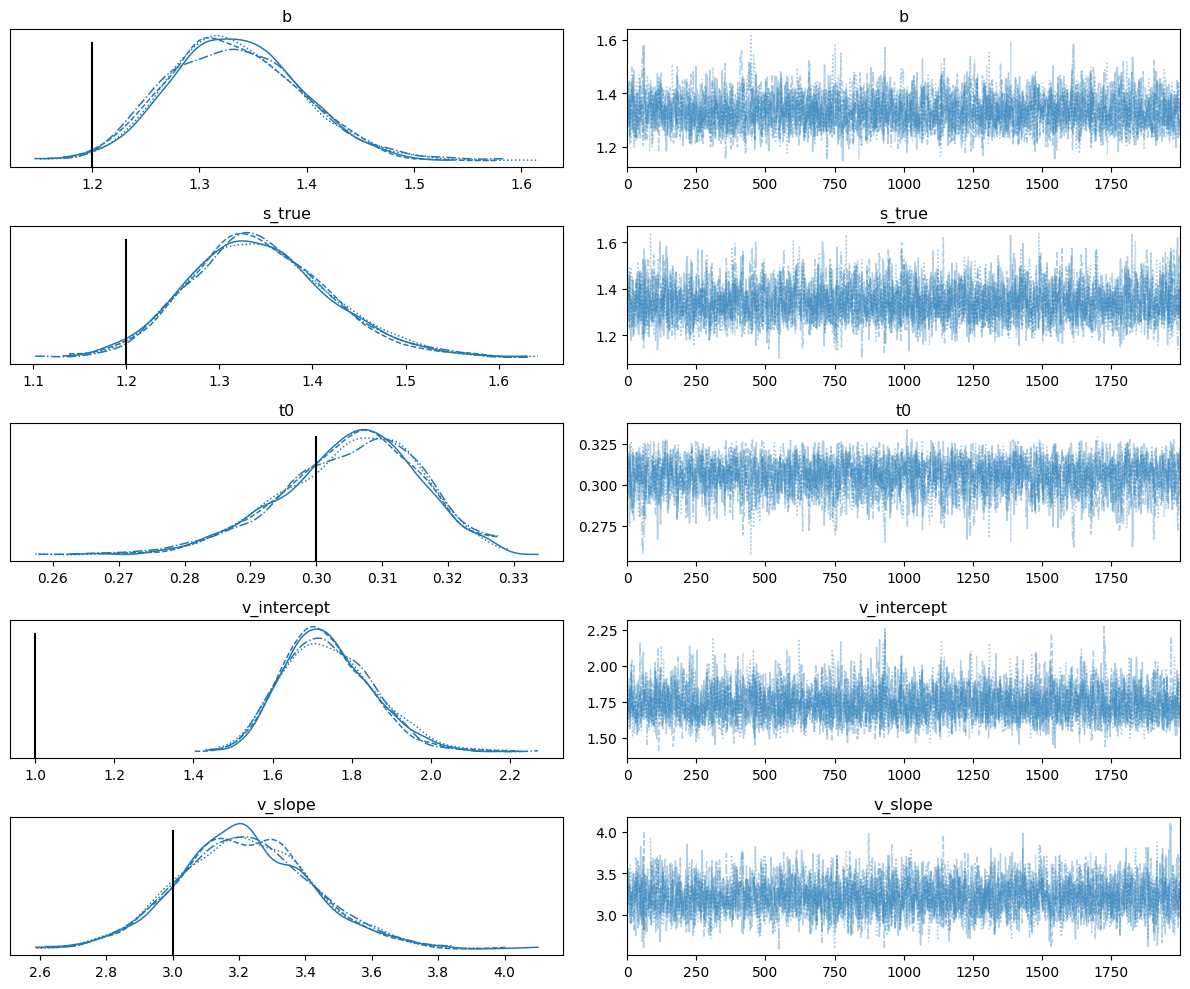

In [74]:
import arviz as az
import matplotlib.pyplot as plt

param_names = ["v_intercept", "v_slope", "s_true", "b", "t0"]

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, samples)})
ax = az.plot_trace(idata)

for i, p in enumerate(sorted(param_names)):
    ax[i, 0].axvline(test_params[p], 0, 0.9, color="k")

plt.tight_layout()